In [20]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [21]:
caminho_arquivo = Path("..") / "DadosBrutos" / "V_EXPORTACAO.csv"
df = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig')

colunas_texto = ['Países', 'Descrição NCM', 'UF do Produto']
for col in colunas_texto:
    df[col] = df[col].str.replace(r'[\r\n]+', ' ', regex=True).str.strip()


In [22]:
print(df.columns.tolist())
print(df.dtypes)

['Ano', 'Países', 'Código NCM', 'Descrição NCM', 'UF do Produto', 'Valor US$ FOB']
Ano               int64
Países           object
Código NCM        int64
Descrição NCM    object
UF do Produto    object
Valor US$ FOB     int64
dtype: object


In [23]:
df.head(10)

,Ano,Países,Código NCM,Descrição NCM,UF do Produto,Valor US$ FOB
0,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,69415459
1,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Pernambuco,14077098
2,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Minas Gerais,12952115
3,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Alagoas,11732058
4,2024,Cabo Verde,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,7383670
5,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Mato Grosso,1914447
6,2024,São Tomé e Príncipe,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,1391228
7,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Goiás,1162085
8,2024,Cabo Verde,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Goiás,1073162
9,2024,Guiné-Bissau,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,544427


In [24]:
print(df['Código NCM'].nunique())
print(df['Código NCM'].count())  


50
1576


NCM tem 8 dígitos, alguns NCMs começam com `0`. 

In [25]:
df['Código NCM'].astype(str).str.len().value_counts()

Código NCM
8    1431
7     145
Name: count, dtype: int64

In [26]:
# confirmando que a correção nos ncms 
print(df['Código NCM'].astype(str).str.len().value_counts())
print(df['Código NCM'].unique())

Código NCM
8    1431
7     145
Name: count, dtype: int64
[17019900 17049020 20098990 21069010 21039029 18050000 19019090 21069029
 20059900 21039021 19023000 12119090 18069000 21021090 19030000 20052000
 19041000  8011100  7129090 11041200 19012090 18061000 21041011 11029000
 28363000  9092100 21023000 12040090 12079990  9096120 17019100  9096110
  9109900  9081100  9041200 12119010  9042200  9041100  9062000  9103000
 11081200  1012900 21069021  9061100  9101200  9071000  9081200 21041019
 35030019 28369913]


Teste com 1 NCM 

In [27]:
ncm_ = 17019900 
df_ncm = df[df['Código NCM'] == ncm_]
df_ncm.head(10)

,Ano,Países,Código NCM,Descrição NCM,UF do Produto,Valor US$ FOB
0,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,69415459
1,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Pernambuco,14077098
2,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Minas Gerais,12952115
3,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Alagoas,11732058
4,2024,Cabo Verde,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,7383670
5,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Mato Grosso,1914447
6,2024,São Tomé e Príncipe,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,1391228
7,2024,Angola,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Goiás,1162085
8,2024,Cabo Verde,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Goiás,1073162
9,2024,Guiné-Bissau,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Paulo,544427


In [28]:
df_ncm_agregado = df_ncm.groupby(['Países', 'Ano'])['Valor US$ FOB'].sum().reset_index()
df_ncm_agregado

,Países,Ano,Valor US$ FOB
0,Angola,2014,177695553
1,Angola,2015,81107917
2,Angola,2016,115705438
3,Angola,2017,192480479
4,Angola,2018,92830641
5,Angola,2019,116149443
6,Angola,2020,66194523
7,Angola,2021,39640529
8,Angola,2022,106901320
9,Angola,2023,31697089


In [29]:
anos_completos = list(range(2014, 2024))
paises_palop = ['Angola', 'Cabo Verde', 'Guiné-Bissau', 'Moçambique', 'São Tomé e Príncipe']

series_por_pais = {}
for pais in paises_palop:
    dados_pais = df_ncm_agregado[df_ncm_agregado['Países'] == pais]
    valores = []
    for ano in anos_completos:
        linha = dados_pais[dados_pais['Ano'] == ano]
        valores.append(int(linha['Valor US$ FOB'].values[0] if len(linha) > 0 else 0))
    series_por_pais[pais] = valores

series_por_pais

{'Angola': [177695553,
  81107917,
  115705438,
  192480479,
  92830641,
  116149443,
  66194523,
  39640529,
  106901320,
  31697089],
 'Cabo Verde': [6397773,
  4735132,
  6216235,
  7123372,
  2994116,
  3436008,
  3555219,
  4357672,
  4507521,
  6312071],
 'Guiné-Bissau': [1091946,
  901397,
  618935,
  1285907,
  911406,
  923120,
  1546544,
  252447,
  226157,
  362765],
 'Moçambique': [0, 687118, 123201, 0, 0, 1778, 2647, 133632, 809, 711814],
 'São Tomé e Príncipe': [0,
  47351,
  140098,
  776829,
  283153,
  616785,
  885386,
  1296390,
  1165326,
  1293790]}

In [30]:
pais_escolhido = "Moçambique"
valores = series_por_pais[pais_escolhido]

for i in range(len(valores)):
    if valores[i] == 0:
        print(anos_completos[i], "→ zero")

2014 → zero
2017 → zero
2018 → zero


Verificando Presença

In [31]:
def calcular_presenca(valores):
    inicio = None
    for i in range(len(valores)):
        if valores[i] > 0:
            inicio = i
            break

    if inicio is None:
        return -1

    total_anos = 0
    anos_com_valor = 0
    for i in range(inicio, len(valores)):
        total_anos = total_anos + 1
        if valores[i] > 0:
            anos_com_valor = anos_com_valor + 1

    proporcao = anos_com_valor / total_anos
    if proporcao == 1.0:
        return 1
    else:
        return 0

In [32]:
for pais, valores in series_por_pais.items():
    resultado = calcular_presenca(valores)
    print(pais, "→", resultado)

Angola → 1
Cabo Verde → 1
Guiné-Bissau → 1
Moçambique → 0
São Tomé e Príncipe → 1


In [33]:
for pais, valores in series_por_pais.items():
    resultado = calcular_presenca(valores)
    print(pais)
    print("  série:", valores)
    print("  presença:", resultado)
    print()

Angola
  série: [177695553, 81107917, 115705438, 192480479, 92830641, 116149443, 66194523, 39640529, 106901320, 31697089]
  presença: 1

Cabo Verde
  série: [6397773, 4735132, 6216235, 7123372, 2994116, 3436008, 3555219, 4357672, 4507521, 6312071]
  presença: 1

Guiné-Bissau
  série: [1091946, 901397, 618935, 1285907, 911406, 923120, 1546544, 252447, 226157, 362765]
  presença: 1

Moçambique
  série: [0, 687118, 123201, 0, 0, 1778, 2647, 133632, 809, 711814]
  presença: 0

São Tomé e Príncipe
  série: [0, 47351, 140098, 776829, 283153, 616785, 885386, 1296390, 1165326, 1293790]
  presença: 1



In [34]:
def calcular_interrupcao(valores):
    inicio = None
    for i in range(len(valores)):
        if valores[i] > 0:
            inicio = i
            break

    if inicio is None:
        return -1

    total_anos = 0
    anos_zerados = 0
    for i in range(inicio, len(valores)):
        total_anos = total_anos + 1
        if valores[i] == 0:
            anos_zerados = anos_zerados + 1

    proporcao_zeros = anos_zerados / total_anos
    if proporcao_zeros == 0:
        return 1
    elif proporcao_zeros <= 0.5:
        return 0
    else:
        return -1

In [35]:
for pais, valores in series_por_pais.items():
    resultado = calcular_interrupcao(valores)
    print(pais, "→", resultado)

Angola → 1
Cabo Verde → 1
Guiné-Bissau → 1
Moçambique → 0
São Tomé e Príncipe → 1


In [36]:
def calcular_tendencia(anos, valores):
    anos_ativos = []
    valores_ativos = []
    for i in range(len(valores)):
        if valores[i] > 0:
            anos_ativos.append(anos[i])
            valores_ativos.append(valores[i])

    if len(anos_ativos) < 2:
        return 0

    inclinacao, intercepto = np.polyfit(anos_ativos, valores_ativos, 1)

    if inclinacao > 0:
        return 1
    elif inclinacao < 0:
        return -1
    else:
        return 0

In [37]:
for pais, valores in series_por_pais.items():
    resultado = calcular_tendencia(anos_completos, valores)
    print(pais, "→", resultado)

Angola → -1
Cabo Verde → -1
Guiné-Bissau → -1
Moçambique → -1
São Tomé e Príncipe → 1


Tendência de São Tomé e Príncipe: 1


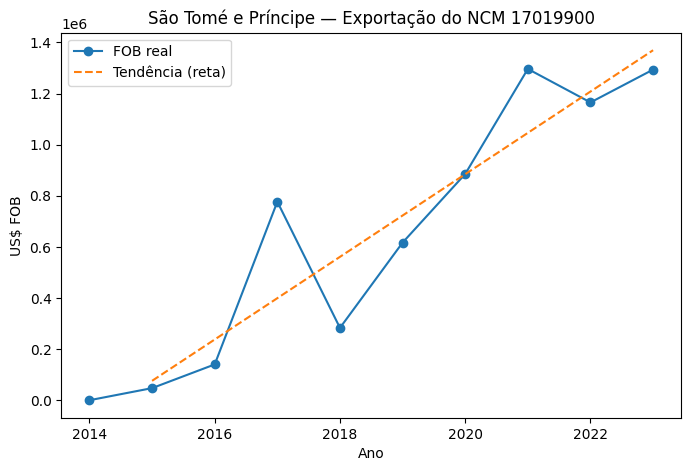

In [38]:
pais_escolhido = "São Tomé e Príncipe"
valores = series_por_pais[pais_escolhido]

anos_ativos = []
valores_ativos = []
for i in range(len(valores)):
    if valores[i] > 0:
        anos_ativos.append(anos_completos[i])
        valores_ativos.append(valores[i])

inclinacao, intercepto = np.polyfit(anos_ativos, valores_ativos, 1)

linha_tendencia = []
for ano in anos_ativos:
    linha_tendencia.append(inclinacao * ano + intercepto)

resultado = calcular_tendencia(anos_completos, valores)
print(f"Tendência de {pais_escolhido}: {resultado}")

plt.figure(figsize=(8,5))
plt.plot(anos_completos, valores, marker='o', label='FOB real')
plt.plot(anos_ativos, linha_tendencia, linestyle='--', label='Tendência (reta)')
plt.title(f"{pais_escolhido} — Exportação do NCM {ncm_}")
plt.xlabel("Ano")
plt.ylabel("US$ FOB")
plt.legend()
plt.show()

In [39]:
def calcular_continuidade_recente(valores, n=3):
    posicao_inicio = len(valores) - n

    ativos = 0
    for i in range(posicao_inicio, len(valores)):
        if valores[i] > 0:
            ativos = ativos + 1

    if ativos == n:
        return 1
    elif ativos == 0:
        return -1
    else:
        return 0

In [40]:
for pais, valores in series_por_pais.items():
    resultado = calcular_continuidade_recente(valores)
    print(pais, "→", resultado)

Angola → 1
Cabo Verde → 1
Guiné-Bissau → 1
Moçambique → 1
São Tomé e Príncipe → 1


In [41]:
for pais, valores in series_por_pais.items():
    posicao_inicio = len(valores) - 3
    ultimos_3 = valores[posicao_inicio:]
    resultado = calcular_continuidade_recente(valores)
    print(pais)
    print("  últimos 3 anos:", ultimos_3)
    print("  continuidade:", resultado)
    print()

Angola
  últimos 3 anos: [39640529, 106901320, 31697089]
  continuidade: 1

Cabo Verde
  últimos 3 anos: [4357672, 4507521, 6312071]
  continuidade: 1

Guiné-Bissau
  últimos 3 anos: [252447, 226157, 362765]
  continuidade: 1

Moçambique
  últimos 3 anos: [133632, 809, 711814]
  continuidade: 1

São Tomé e Príncipe
  últimos 3 anos: [1296390, 1165326, 1293790]
  continuidade: 1

